# Building Distributions

The purpose of this notebook is to build some canonical distributions used for convergence testing. 
These include
- normal distribution
- geometric distribution
- binomial distribution


In [60]:
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from tabulate import tabulate



We begin by building a normal distribution 
$$
 X \sim N(0, 2)
$$

Where we want to estimate this quantity 
$$
E(X^2)
$$

using $N$ samples $X_1, \ldots, X_N$ and estimator:

$$
\mu_N  = \frac{1}{N} \sum_{i=1}^N X_i^2
$$

**The theory**

Here is to see that the standard error of this MC method estimator is proportional to the inverse square root of the number of samples taken from the distribution.

\begin{align*}
    SE \propto \frac{1}{\sqrt{N}}
\end{align*}



(array([1., 0., 1., 0., 3., 0., 2., 1., 1., 1.]),
 array([-5.92905768, -4.85206891, -3.77508014, -2.69809137, -1.6211026 ,
        -0.54411383,  0.53287494,  1.60986371,  2.68685248,  3.76384125,
         4.84083002]),
 <BarContainer object of 10 artists>)

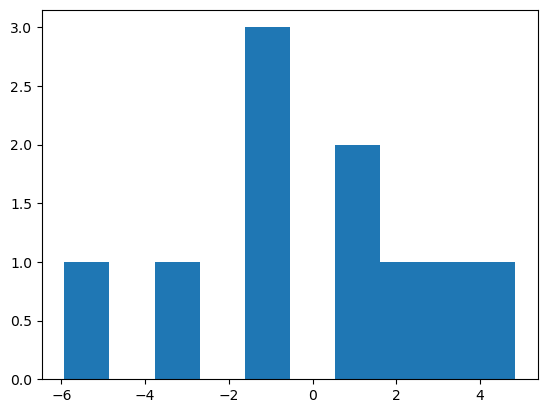

In [ ]:
# building a distribution:

# seeding
rng = np.random.default_rng(seed=42)

# get an array of norm rnds
# generate N samples:
N = 10
sigma = 2.0
true_mean = 0.0
X = rng.normal(loc=true_mean, scale=sigma, size=N)

# make normal distro. check with plot
plt.hist(rnd_array)


# Build an Estimator


In [41]:
# lets build estimator for quantity E(X^2).

# for a X~N(0, 2), we get 4? Var(X) = E(X^2) - E(X)^2 = E(X^2) = 4. 


# to build the estimator design it:
# seeding
rng = np.random.default_rng(seed=42)

# Distribution Params.
sigma = 2.0
true_mean = 0.0

# Get N numbers. This will loop later. 

# Storing data.
estimator_mean = []
estimator_sdev = []
estimator_rmse = []
# error_abs_mean = []
runtime_mean = []

# Executing Loop. 
log_sample_size = [10 ** i for i in range(1, 7)]
repeat_draw_size = 100
repeat_draws = range(1, repeat_draw_size + 1) # Doing 1 draw per sample size is noisy. Make several draws.
for N in log_sample_size:
    # Storing data.
    estimator = []
    error_abs = []
    runtime = []
    for draw in repeat_draws:
        time_start = time.perf_counter()

        # Draw the random numbers.
        X = rng.normal(loc=true_mean, scale=sigma, size=N)

        # Calculate QOIs.
        mu_n = sum([x ** 2 / N for x in X])
        estimator.append(mu_n)
        # error_abs.append(abs(mu_n - sigma ** 2))

        time_end = time.perf_counter()
        runtime.append(time_end - time_start)
    
    # Compute mean of estimates.
    estimator_mean.append(sum(estimator) / repeat_draw_size)
    # error_abs_mean.append(sum(error_abs) / repeat_draw_size)
    runtime_mean.append(sum(runtime) / repeat_draw_size)

    # Compute stan dev of estimates.
    # This is a biased estimator of stan dev but for large sample size (repeat_draw_size), the difference is negligible.
    estimator_sdev_ = np.sqrt(sum([(x - estimator_mean[-1]) ** 2 for x in estimator]) / (repeat_draw_size - 1))
    estimator_rmse_ = np.sqrt(sum([(sigma ** 2 - y_hat) ** 2 for y_hat in estimator])) / repeat_draw_size
    estimator_sdev.append(estimator_sdev_)
    estimator_rmse.append(estimator_rmse_)



In [ ]:
# Using estimated output data, estimate the fit.
from numpy.polynomial import Polynomial

x_data = np.log(log_sample_size)
y_data = np.log(estimator_rmse)
best_fit_line = Polynomial.fit(x_data, y_data, deg=1)

y_intercept, best_fit_slope = best_fit_line.convert().coef
print(f"best_fit_slope: {best_fit_slope}")


best_fit_slope: -0.5037828366284345


best_fit_slope: -0.5037828366284345


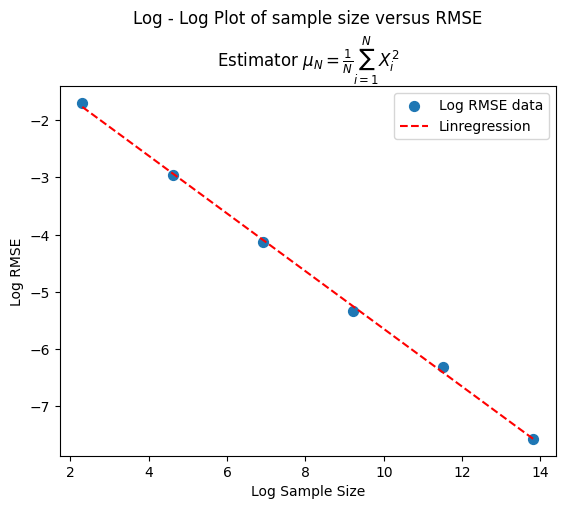

In [59]:
# compare against theory

# MC theory says:
# Error proportional to 1/sqrt(N)

print(f"best_fit_slope: {best_fit_slope}")


plt.scatter(x_data, y_data, s=50, label="Log RMSE data");
plt.plot(x_data, list(map(lambda x: best_fit_slope * x + y_intercept, x_data)), color="red", linestyle="--", label="Linregression");

plt.title("Log - Log Plot of sample size versus RMSE" "\n" r"Estimator $\mu_N  = \frac{1}{N} \sum_{i=1}^N X_i^2$");
plt.ylabel("Log RMSE");
plt.xlabel("Log Sample Size");
plt.legend();

(3.0, 5.0)

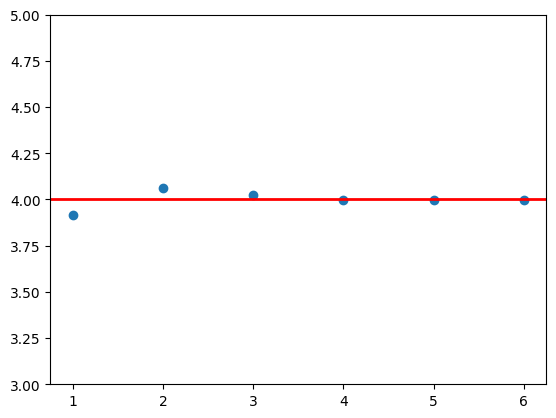

In [44]:

# Plot to verify 
x_space = [np.log10(x) for x in log_sample_size]
plt.scatter(x_space, estimator_mean)
plt.axhline(y=sigma ** 2, color="red", linestyle="-", linewidth=2)
# plt.xlim(0, 5)
plt.ylim(3, 5)

# Extension 1: Antithetic Variate

In the antithetic path reduces the variance of the MC simulation results with the goal of improving the rate of convergence.

https://en.wikipedia.org/wiki/Antithetic_variates

The method is as follows:

Take each sample path and with it, take an antithetic path:

\begin{align*}
    \{ \epsilon_1, \epsilon_2, \ldots, \epsilon_M \} \\
    %
    \{- \epsilon_1, - \epsilon_2, \ldots, -\epsilon_M \} \\
\end{align*}

This technique reduces the number of samples taken to generate $N$ paths.  It also reduces the variance of the sample paths. 


Let us estimate some quantity:

\begin{align*}
    \theta = E\left( h(X) \right) = E(Y)
\end{align*}

Suppose to calculate an estimate we gather two samples $Y_1, Y_2$. An **unbiased** estimator of $\theta$ is:

\begin{align*}
    \hat{\theta} = \frac{Y_1 + Y_2}{2}. 
\end{align*}

We can calculate 

\begin{align*}
    Var(\hat{\theta}) = \frac{Var(Y_1) + Var(Y_2) + 2 Cov(Y_1, Y_2)}{4}
\end{align*}

The first two terms above are always positive, while the covariance can be negative, and maximally so when $Y_1 = -Y_2$.



**One example here is** 

Supose $X \sim U[0,1]$ with one sample: $u = \{u_1, u_2, \ldots, u_M \}$. How would we build the antithetic sample? 

As follows:

\begin{align*}
    u' = \{1 - u_1, 1 - u_2, \ldots, 1 - u_M \}.
\end{align*}

Note that these would satisfy $u` \sim U[0, 1]$ as well.

Now suppose we want to estimate 

$$
I = \int_0^1 \frac{1}{1 + x} dx,
$$

with the exact solution $I = ln(2) \approx 0.69314$.

One way to think about this integral is expected value of $f(U)$ where $U \sim U[0,1]$ and $f(U) = \frac{1}{1 + U}$, and by the definition of expected value:

$$
    E(f(U)) = \frac{1}{1 - 0} \int_0^1 f(U) \cdot 1 \ dU = \frac{1}{1 - 0} \int_0^1 \frac{1}{1 + x} \cdot 1 \ dx
    %

$$

Suppose we then esimate $E(f(U))$ using the unbiased estimate: 

$$\hat{\theta}_A = \hat{E}_A = \frac{1}{2M} \sum_{i = 1}^{2M} \frac{1}{1 + u_i} $$

Given antitetical values $u, u'$, we would estimate 

$$\hat{\theta}_B = \hat{E}_B =  \frac{1}{2M} \left( \sum_{i = 1}^{M} \frac{1}{1 + u_i} + \sum_{i = 1}^{M} \frac{1}{1 + u_i'} \right)$$

Why the $2M$ for calculation $A$? because to compare equal sized samples we have to collect twice as many direct samples for $u$ versus if we use the antithetic sampling, which is free, because we just use what we already have an convert as $u' = 1 - u$.




# Antithetic Buildout

[0.77395605 0.43887844 0.85859792 0.69736803 0.09417735 0.97562235
 0.7611397  0.78606431 0.12811363 0.45038594 0.37079802 0.92676499
 0.64386512 0.82276161 0.4434142  0.22723872 0.55458479 0.06381726
 0.82763117 0.6316644 ]
[0.75808774 0.35452597 0.97069802 0.89312112 0.7783835  0.19463871
 0.466721   0.04380377 0.15428949 0.68304895 0.24191226 0.64547403
 0.02930198 0.10687888 0.2216165  0.80536129 0.533279   0.95619623
 0.84571051 0.31695105]
theta_A: 0.5738421997960513
theta_Bp: 0.5


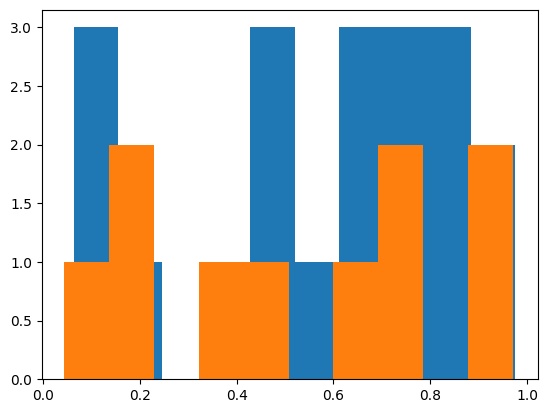

In [96]:
import numpy as np

rng = np.random.default_rng(seed=42)

# Collect sampling and antithetic sample.
M = 10
u_A = rng.uniform(0, 1.0, 2 * M)
u_B = rng.uniform(0, 1.0, M)
u_Bp = np.concatenate((u_B, (1 - u_B)))

print(u_A)
print(u_Bp)

plt.hist(u_A);
plt.hist(u_B);
# plt.hist(u_Bp, label="antithetic");

# Build the estimates:

theta_A = sum(u_A) / (2 * M)
theta_Bp = sum(u_Bp) / (2 * M)

print(f"theta_A: {theta_A}")
print(f"theta_Bp: {theta_Bp}")





[0.75808774 0.35452597 0.97069802 0.89312112 0.7783835  0.19463871
 0.466721   0.04380377 0.15428949 0.68304895 0.24191226 0.64547403
 0.02930198 0.10687888 0.2216165  0.80536129 0.533279   0.95619623
 0.84571051 0.31695105]
[0.77395605 0.43887844 0.85859792 0.69736803 0.09417735 0.97562235
 0.7611397  0.78606431 0.12811363 0.45038594 0.37079802 0.92676499
 0.64386512 0.82276161 0.4434142  0.22723872 0.55458479 0.06381726
 0.82763117 0.6316644 ]
